#Transfer Learning with Med MNIST.

In this assignment you will use transfer learning to train a model of your choice on a sub-dataset from the [MedMNIST datasets](https://medmnist.com/). ![](https://github.com/tonyscan6003/etivities/blob/main/medmnist.JPG?raw=true)

* The [MedMNIST package](https://github.com/MedMNIST/MedMNIST/blob/main/examples/getting_started.ipynb) allows the data to be imported directly as a pytorch dataset.

* You may select any of the datasets using Multi-class/binary classification. The goal is to acheve accuracy levels comparable to the benchmark results shown on the medmnist site. Dataloading for pytorch is setup in the notebook, you wil need to modify the code slightly depending on your dataset of choice.

* Some datasets use black and white images, so you will need to [at least concatenate](https://towardsdatascience.com/transfer-learning-on-greyscale-images-how-to-fine-tune-pretrained-models-on-black-and-white-9a5150755c7a) the input image channels (to 3 channels) for compatibility with the models pre-trained on imageNet.

* Some of the MedMNIST datasets don't contain too much data so Data augmentation may be essentila essential to avoid overfitting. In pytorch data augmentation is performed using the [transforms.v2](https://pytorch.org/vision/main/transforms.html) modules.

* In this notebook: You will need to import a model, and perform training. Tranfer Learning for computer vision is detailed [here](https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html)

* [Tensorboard can be imported](https://pytorch.org/tutorials/beginner/introyt/tensorboardyt_tutorial.html) to display results.

* Please only include one example of transfer learning in the submitted notebook. Making sure training curves/results are clearly visible. If you have trained additional transfer learning models (i.e. that were less successful) please add this as a table or report at the end of the notebook and/or in your final forum post.




# 1. Install & Import Packages

In [3]:
!pip install medmnist
!pip install torchinfo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [medmnist]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

from torchvision import models
from torchvision.transforms import v2, ToTensor

from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter

import matplotlib.pyplot as plt
import numpy as np

import medmnist
from medmnist import INFO, Evaluator

from sklearn.metrics import classification_report, confusion_matrix


2025-11-16 23:46:07.993243: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 2. Setup & Import Dataset
The [MedMNSIT](https://medmnist.com/) package (imported above) makes available several medical datasets available to access.

You can change the `data_flag` variable (dataset names are all lower case letters) to the dataset of your choice (Take care to note the parameters e.g. number of input channels below that will affect your model)



In [19]:
import medmnist
from medmnist import INFO, Evaluator

data_flag = 'bloodmnist'
download = True

BATCH_SIZE = 64
IMG_SIZE = 224   # for pretrained ImageNet models

info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])
n_channels = info['n_channels']
n_classes = len(info['label'])

print(info)
print ("================================================================================")
print('Type of Machine Learning Task = ',task)
print('Number of Input Data Channels = ',n_channels)
print('Number of Classes = ',n_classes)
print('The batch size for this dataset will be = ',BATCH_SIZE)

DataClass = getattr(medmnist, info['python_class'])

{'python_class': 'BloodMNIST', 'description': 'The BloodMNIST is based on a dataset of individual normal cells, captured from individuals without infection, hematologic or oncologic disease and free of any pharmacologic treatment at the moment of blood collection. It contains a total of 17,092 images and is organized into 8 classes. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images with resolution 3×360×363 pixels are center-cropped into 3×200×200, and then resized into 3×28×28.', 'url': 'https://zenodo.org/records/10519652/files/bloodmnist.npz?download=1', 'MD5': '7053d0359d879ad8a5505303e11de1dc', 'url_64': 'https://zenodo.org/records/10519652/files/bloodmnist_64.npz?download=1', 'MD5_64': '2b94928a2ae4916078ca51e05b6b800b', 'url_128': 'https://zenodo.org/records/10519652/files/bloodmnist_128.npz?download=1', 'MD5_128': 'adace1e0ed228fccda1f39692059dd4c', 'url_224': 'https://zenodo.org/records/10519652/files/bloodmnist_224.npz

### Transforms

Transforms:
You can update the functions below with appropriate transforms for your particular use case.

* As well as being suitable for data augmention for image classification, the transforms.v2 package of torchvision extends transforms for object detection and segmentation tasks. An illustration of the transforms is shown [here](https://pytorch.org/vision/main/auto_examples/transforms/plot_transforms_illustrations.html#sphx-glr-auto-examples-transforms-plot-transforms-illustrations-py).
* Normalisation based on ImageNet parameters is included already. This should be used with all models pre-trained on ImageNet  





In [22]:
train_transforms = v2.Compose([
    v2.ToDtype(torch.float32, scale=True),
    ToTensor(),
    v2.Grayscale(num_output_channels=3),   # Convert to 3-channel
    v2.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    v2.RandomHorizontalFlip(),
    v2.RandomRotation(10),
    v2.ColorJitter(brightness=0.1, contrast=0.1),
    v2.Normalize(mean=[0.485, 0.456, 0.406], 
                 std=[0.229, 0.224, 0.225])
])

test_transforms = v2.Compose([
    v2.ToDtype(torch.float32, scale=True),
    ToTensor(),
    v2.Grayscale(num_output_channels=3),
    v2.Resize((IMG_SIZE, IMG_SIZE)),
    v2.Normalize(mean=[0.485, 0.456, 0.406], 
                 std=[0.229, 0.224, 0.225])
])


Setup your Medmnist dataset.
* The convolution part of pre-trained networks (such as resnet) are compatable with any size input image. However they were trained on 224 x 224 size images, with early layers finding small scale features and deeper layers finding large scale features.
* For this transfer learning application to medical data, the gap between the original ImageNet domain and the medical images is wide. Therefore the size/scale of the input images is less important, however in general we would expect better performance with the larger input images (as they contain more features at different scales).
* You can add the `size=224` parameter to the dataset object calls, to load full size images. Only do this once you are confident in your training methodology (or if the dataset is small), as training with full size images will take longer.


### Load Dataset

In [25]:
# Download training data from open datasets.
train_dataset = DataClass(split='train', transform=train_transforms, download=download, size=IMG_SIZE)
val_dataset   = DataClass(split='val',   transform=test_transforms, download=download, size=IMG_SIZE)
test_dataset  = DataClass(split='test',  transform=test_transforms, download=download, size=IMG_SIZE)


100%|██████████████████████| 1540731655/1540731655 [04:40<00:00, 5487864.62it/s]


Using downloaded and verified file: /Users/owner/.medmnist/bloodmnist_224.npz
Using downloaded and verified file: /Users/owner/.medmnist/bloodmnist_224.npz


The `Dataset` is passed as an argument to `DataLoader`. This wraps an
iterable over the dataset, and supports automatic batching, sampling,
shuffling and multiprocess data loading.

In [28]:
# Create data loaders.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

for X, y in test_loader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 3, 224, 224])
Shape of y: torch.Size([64, 1]) torch.int64


Plot some example augmented images

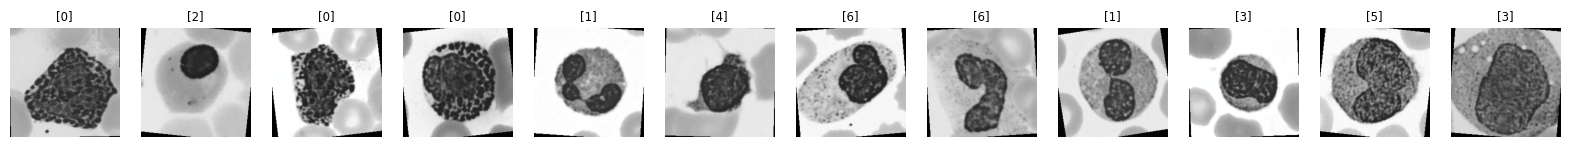

In [30]:
# Output next batch from dataloader
dataiter = iter(train_loader)
image_batch, labels_batch = next(dataiter)

# Use matplotlib to plot a sample of images

i=0
n_plots = 12 # number of plots
f, axarr = plt.subplots(1,n_plots,figsize=(20,10))

for image in image_batch[0:n_plots,:,:,:]:
  disp_image =  torch.permute(image,(2,1,0)).numpy() # return image to cpu for display and permute to channels last
  mean = np.array([0.485, 0.456, 0.406])
  std = np.array([0.229, 0.224, 0.225])
  disp_image = std * disp_image + mean
  disp_image = np.clip(disp_image, 0, 1)
  axarr[i].imshow(disp_image[:,:,:])
  axarr[i].axis("off")
  axarr[i].set_title(labels_batch[i].numpy(),fontsize='small')
  i = i+1


# 3. Define Transfer Learning model (ResNet18)
Pytorch has an inbuilt [models package](https://pytorch.org/vision/stable/models.html) that allows loading of popular models with pre-trained weights.

* We want to add an additional classifier stage (to the output of the network). How to setup the [model is detailed here](https://discuss.pytorch.org/t/load-only-a-part-of-the-network-with-pretrained-weights/88397/2).
* This additional classifier may just be a single layer or a cascade of fully connected layers with dropout.
* Note that the number of parameters in the convolutional part of the model will be same no what the input size is set to. However the output feature map size will vary with input image size (small for small image, large for large image). This means the number of parameters in the additional classifier will change depending on input image size.


In [33]:
# Get cpu, gpu or mps device for training.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cpu device


In [35]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Freeze convolution layers
for param in model.parameters():
    param.requires_grad = False

# Replace classifier head
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, n_classes)
)

model = model.to(device)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/owner/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████████████████████████████████| 44.7M/44.7M [00:06<00:00, 7.61MB/s]


# 4. Optimisation & Training Loop

Define a training loop that prints the loss from the training and validation set at least every epoch.
* You may choose to make the validation loss calculations more frequent so you can ensure training is progressing satisfactorily (especially with larger datasets).

* You can use tensorboard to visualise the [loss curves](https://pytorch.org/docs/stable/tensorboard.html))

* For multi-class classification classification problem we will use the  [CrossEntropy loss](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html). In this pytorch function, the input is the un-normalised logit value.

* You may  have to use [torch.squeeze](https://pytorch.org/docs/stable/generated/torch.squeeze.html) to reduce the dimensionality of the label tensor before passing it to the loss function (this due to how the dataset is configured and the loss will only accept 0D or 1D inputs)

### Loss, Optimizer, Scheduler

- Only classifier params trainable
- CrossEntropyLoss
- StepLR scheduler for stable training

In [38]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
scheduler = StepLR(optimizer, step_size=5, gamma=0.1)


### Training & Validation Loop (Structured + TensorBoard)

In [41]:
writer = SummaryWriter("runs/bloodmnist_resnet18")

def train_one_epoch(epoch):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.squeeze().to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    acc = 100 * correct / total
    writer.add_scalar("Loss/Train", train_loss / len(train_loader), epoch)
    writer.add_scalar("Accuracy/Train", acc, epoch)
    return train_loss / len(train_loader), acc


def validate(epoch):
    model.eval()
    val_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.squeeze().to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

    acc = 100 * correct / total
    writer.add_scalar("Loss/Val", val_loss / len(val_loader), epoch)
    writer.add_scalar("Accuracy/Val", acc, epoch)
    return val_loss / len(val_loader), acc


### Run Training

In [44]:
EPOCHS = 12

for epoch in range(EPOCHS):
    train_l, train_a = train_one_epoch(epoch)
    val_l, val_a = validate(epoch)
    scheduler.step()

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Acc: {train_a:.2f}% | Val Acc: {val_a:.2f}%")


Epoch 1/12 | Train Acc: 68.22% | Val Acc: 81.95%
Epoch 2/12 | Train Acc: 78.58% | Val Acc: 83.24%
Epoch 3/12 | Train Acc: 79.65% | Val Acc: 86.68%
Epoch 4/12 | Train Acc: 80.26% | Val Acc: 85.28%
Epoch 5/12 | Train Acc: 81.44% | Val Acc: 83.59%
Epoch 6/12 | Train Acc: 81.77% | Val Acc: 87.21%
Epoch 7/12 | Train Acc: 82.86% | Val Acc: 87.21%
Epoch 8/12 | Train Acc: 82.54% | Val Acc: 88.43%
Epoch 9/12 | Train Acc: 82.22% | Val Acc: 88.03%
Epoch 10/12 | Train Acc: 83.01% | Val Acc: 87.97%
Epoch 11/12 | Train Acc: 82.72% | Val Acc: 88.55%
Epoch 12/12 | Train Acc: 83.12% | Val Acc: 88.08%


Initialise Tensorboard (use of tensorboard in colab notebooks is [detailed here](https://colab.research.google.com/github/tensorflow/tensorboard/blob/master/docs/tensorboard_in_notebooks.ipynb)). A [Pytorch tutorial](https://pytorch.org/tutorials/beginner/introyt/tensorboardyt_tutorial.html) shows how to setup the training and validation loop with pytorch.


In [51]:
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter('runs')

# 5. Evaluate Model
You will need to setup an evaluation loop for the model to assess it's performance on the test dataset.

You may also obtain a classification report after final evaluation of the test dataset with the model using the code below. A confusion matrix can also be obtained and we will plot a few example images.



In [55]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)

        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels.squeeze().numpy())


### Confusion Matrix & Classification Report

In [57]:
cm = confusion_matrix(y_true, y_pred)
print(classification_report(y_true, y_pred))


              precision    recall  f1-score   support

           0       0.94      0.74      0.83       244
           1       0.88      0.88      0.88       624
           2       0.88      0.92      0.90       311
           3       0.72      0.86      0.79       579
           4       0.86      0.91      0.89       243
           5       0.93      0.61      0.74       284
           6       0.91      0.94      0.93       666
           7       0.98      0.99      0.99       470

    accuracy                           0.88      3421
   macro avg       0.89      0.86      0.87      3421
weighted avg       0.88      0.88      0.87      3421



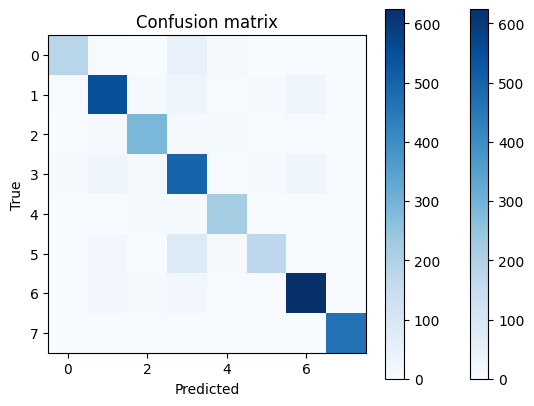

In [63]:
#https://scikit-learn.org/0.16/auto_examples/model_selection/plot_confusion_matrix.html
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
def plot_confusion_matrix(cm, title='Confusion matrix', cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("True")
    #plt.show()

plot_confusion_matrix(cm)

In [65]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=classes))

NameError: name 'classes' is not defined

 # Comments about your Approach